# Lesion-Based (Calcification, Mass) Training Experiments for all CNNs

* VGG16
* ResNet50
* DenseNet121
* MobileNetV2
* EfficientNet-B0

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 566, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 566 (delta 40), reused 64 (delta 27), pack-reused 483 (from 1)
Receiving objects: 100% (566/566), 16.99 MiB | 20.66 MiB/s, done.
Resolving deltas: 100% (289/289), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import generate_class_weight_dict
from src.workflows.dataset_generation import *
from src.workflows.training_and_evaluation import *
from src.common_model_functions import *
from src.experimental_results_functions import generate_results_metrics_df, store_experiment_results
from src.visualizations import *
from src.constants import BATCH_SIZE, CLASSES, PREDICTION_THRESHOLD, EXPERIMENTAL_EPOCHS

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training and validation datasets (containing images) and store them in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training and validation metadata CSV files from drive and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)

In [ ]:
# Calcification-only lesion
train_df_c = train_df[train_df['abnormality type'] == 'calcification']
val_df_c = val_df[val_df['abnormality type'] == 'calcification']

In [ ]:
# Class distributions for Calcification
print(train_df_c['pathology'].value_counts())
print(val_df_c['pathology'].value_counts())

pathology
0.0    767
1.0    401
Name: count, dtype: int64
pathology
0.0    214
1.0    102
Name: count, dtype: int64


In [ ]:
# Mass-only lesion
train_df_m = train_df[train_df['abnormality type'] == 'mass']
val_df_m = val_df[val_df['abnormality type'] == 'mass']

In [ ]:
# Class distributions for Mass
print(train_df_m['pathology'].value_counts())
print(val_df_m['pathology'].value_counts())

pathology
0.0    604
1.0    503
Name: count, dtype: int64
pathology
0.0    143
1.0    128
Name: count, dtype: int64


In [ ]:
# Validation set true labels for evaluation
val_true_labels_c = val_df_c['pathology'].to_numpy()
val_true_labels_m = val_df_m['pathology'].to_numpy()

In [ ]:
# CSV Files to store all experimental results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/lesions_experiment_results.csv"

In [ ]:
# Buffer size for shuffling in training dataset
BUFFER_SIZE_C = len(train_df_c)
BUFFER_SIZE_M = len(train_df_m)
# No. of training samples in Calcification and Mass dataframes for class weight
TOTAL_TRAINING_SAMPLES_C = len(train_df_c)
TOTAL_TRAINING_SAMPLES_M = len(train_df_m)

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Class-Imbalance Handling
class_weights_dict_c = generate_class_weight_dict(train_df_c, CLASSES, TOTAL_TRAINING_SAMPLES_C)
class_weights_dict_m = generate_class_weight_dict(train_df_m, CLASSES, TOTAL_TRAINING_SAMPLES_M)

In [ ]:
# Image preprocessor
baseline_preprocessor = IMAGE_PREPROCESSORS['baseline']

## Calcification lesion only Experiment

#### tf.data Datasets for Calcification-Only Lesion

In [ ]:
# Generate training and validation datasets for Calcification only
train_dataset_c = dataset_preparation(train_df_c, baseline_preprocessor, BUFFER_SIZE_C, BATCH_SIZE, training=True)
val_dataset_c = dataset_preparation(val_df_c, baseline_preprocessor, BUFFER_SIZE_C, BATCH_SIZE, training=False)

In [ ]:
# Select the VGG16 model
vgg16_model_c = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_c, train_time_vgg16_c, peak_memory_vgg16_c = train_selected_model(vgg16_model_c,
                                                                        train_dataset_c,
                                                                        val_dataset_c,
                                                                        EXPERIMENTAL_EPOCHS,
                                                                        early_stopping,
                                                                        class_weights_dict_c)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 28s 497ms/step - accuracy: 0.5445 - auc: 0.5424 - loss: 1.0258 - precision: 0.3723 - recall: 0.4763 - val_accuracy: 0.6519 - val_auc: 0.6056 - val_loss: 0.6701 - val_precision: 0.4474 - val_recall: 0.3333
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 493ms/step - accuracy: 0.5959 - auc: 0.5804 - loss: 0.8593 - precision: 0.4169 - recall: 0.4439 - val_accuracy: 0.6614 - val_auc: 0.6460 - val_loss: 0.6352 - val_precision: 0.4684 - val_recall: 0.3627
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 478ms/step - accuracy: 0.6250 - auc: 0.6059 - loss: 0.8137 - precision: 0.4579 - recall: 0.5012 - val_accuracy: 0.6994 - val_auc: 0.6345 - val_loss: 0.5787 - val_precision: 0.5745 - val_recall: 0.2647
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 493ms/step - accuracy: 0.6173 - auc: 0.6097 - loss: 0.7642 - precision: 0.4439 - recall: 0.4539 - val_accuracy: 0.6835 - val_auc: 0.6440 - val_loss: 0.5704 - val_precision: 0.517

In [ ]:
# Predictions and evaluations using the trained VGG16 model
logits_vgg16_c, predictions_vgg16_c, metrics_dict_vgg16_c, infer_time_vgg16_c = generate_predictions_and_evaluations(vgg16_c,
                                                                                                                     val_dataset_c,
                                                                                                                     val_true_labels_c,
                                                                                                                     PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step - accuracy: 0.7247 - auc: 0.6664 - loss: 0.5226 - precision: 0.6364 - recall: 0.3431


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_c_results_df = generate_results_metrics_df(
    model_name='VGG16',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_vgg16_c,
    train_time=train_time_vgg16_c,
    infer_time=infer_time_vgg16_c,
    peak_memory=peak_memory_vgg16_c,
    experiment_type='lesions'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_c_results_df, 'lesions')

Stored results for 0    Calcification-Only-Lesion
Name: lesion_type, dtype: object lesions


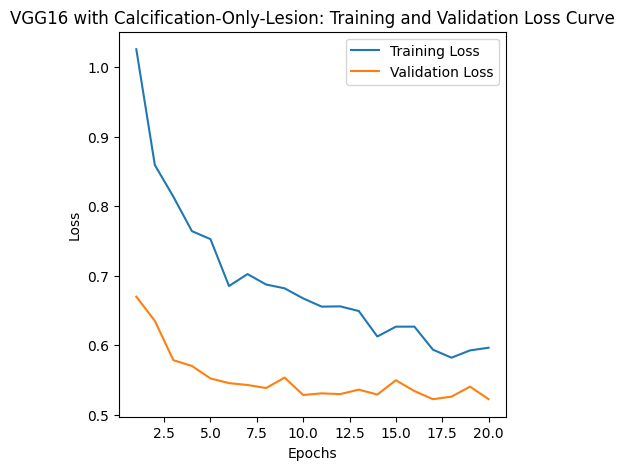

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_c.history, 'VGG16', 'Calcification-Only-Lesion')

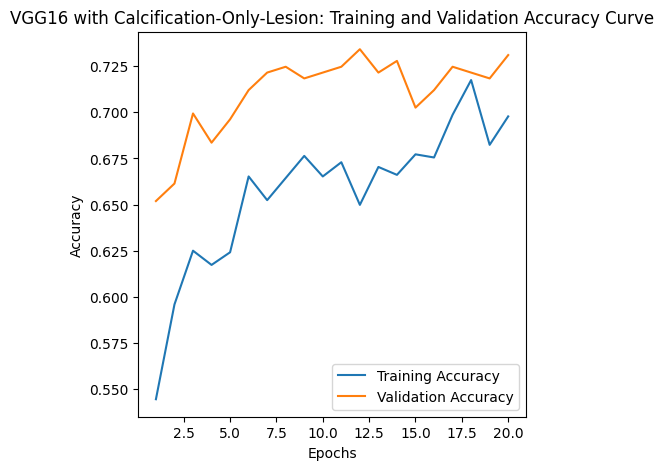

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(vgg16_c.history, 'VGG16', 'Calcification-Only-Lesion')

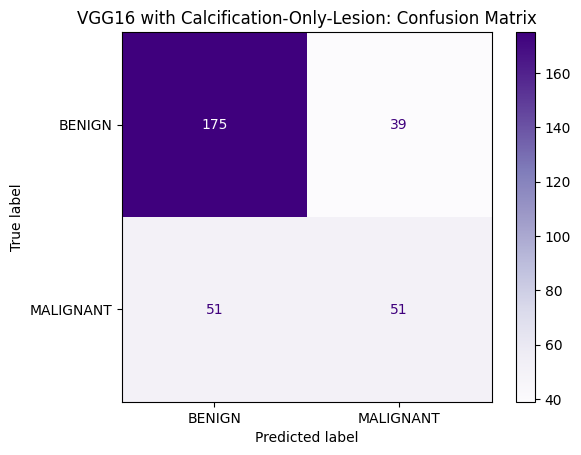

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_c, predictions_vgg16_c, 'VGG16', 'Calcification-Only-Lesion')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_c = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_c, train_time_resnet50_c, peak_memory_resnet50_c = train_selected_model(resnet50_model_c,
                                                                                 train_dataset_c,
                                                                                 val_dataset_c,
                                                                                 EXPERIMENTAL_EPOCHS,
                                                                                 early_stopping,
                                                                                 class_weights_dict_c)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 31s 545ms/step - accuracy: 0.6122 - auc: 0.5849 - loss: 0.7073 - precision: 0.4266 - recall: 0.3766 - val_accuracy: 0.6930 - val_auc: 0.6701 - val_loss: 0.5717 - val_precision: 0.5373 - val_recall: 0.3529
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 502ms/step - accuracy: 0.6627 - auc: 0.6519 - loss: 0.6229 - precision: 0.5097 - recall: 0.4564 - val_accuracy: 0.7057 - val_auc: 0.7061 - val_loss: 0.5674 - val_precision: 0.5517 - val_recall: 0.4706
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 483ms/step - accuracy: 0.6541 - auc: 0.6760 - loss: 0.6126 - precision: 0.4965 - recall: 0.5237 - val_accuracy: 0.7215 - val_auc: 0.6849 - val_loss: 0.5325 - val_precision: 0.6094 - val_recall: 0.3824
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 489ms/step - accuracy: 0.6858 - auc: 0.6787 - loss: 0.5983 - precision: 0.5459 - recall: 0.5037 - val_accuracy: 0.7247 - val_auc: 0.7006 - val_loss: 0.5347 - val_precision: 0.597

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
logits_resnet50_c, predictions_resnet50_c, metrics_dict_resnet50_c, infer_time_resnet50_c = generate_predictions_and_evaluations(resnet50_c,
                                                                                                                                 val_dataset_c,
                                                                                                                                 val_true_labels_c,
                                                                                                                                 PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 391ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 258ms/step - accuracy: 0.6994 - auc: 0.6783 - loss: 0.4922 - precision: 0.5714 - recall: 0.2745


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_c_results_df = generate_results_metrics_df(
    model_name='ResNet50',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_resnet50_c,
    train_time=train_time_resnet50_c,
    infer_time=infer_time_resnet50_c,
    peak_memory=peak_memory_resnet50_c,
    experiment_type='lesions'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_c_results_df, 'lesions')

Stored results for 0    Calcification-Only-Lesion
Name: lesion_type, dtype: object lesions


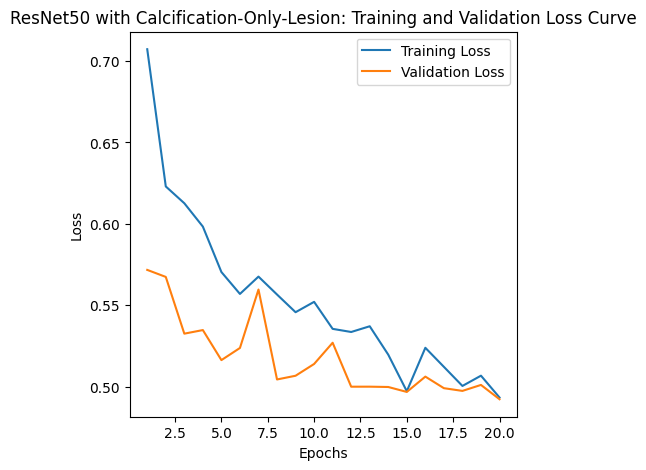

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_c.history, 'ResNet50', 'Calcification-Only-Lesion')

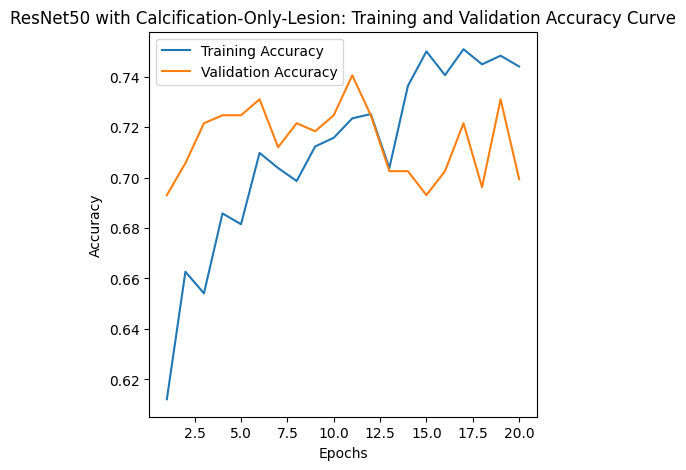

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(resnet50_c.history, 'ResNet50', 'Calcification-Only-Lesion')

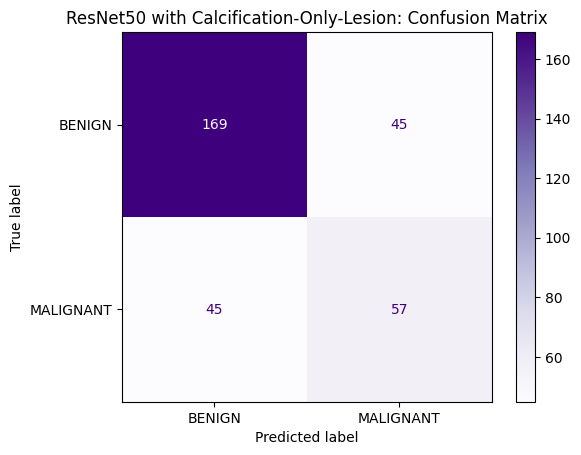

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_c, predictions_resnet50_c, 'ResNet50', 'Calcification-Only-Lesion')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_c = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_c, train_time_densenet121_c, peak_memory_densenet121_c = train_selected_model(densenet121_model_c,
                                                                                          train_dataset_c,
                                                                                          val_dataset_c,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict_c)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 39s 607ms/step - accuracy: 0.5574 - auc: 0.5351 - loss: 1.3042 - precision: 0.3776 - recall: 0.4464 - val_accuracy: 0.6203 - val_auc: 0.6271 - val_loss: 0.8496 - val_precision: 0.4286 - val_recall: 0.5294
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 23s 493ms/step - accuracy: 0.5950 - auc: 0.5642 - loss: 1.1042 - precision: 0.4159 - recall: 0.4439 - val_accuracy: 0.6804 - val_auc: 0.6023 - val_loss: 0.6353 - val_precision: 0.5102 - val_recall: 0.2451
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 580ms/step - accuracy: 0.5942 - auc: 0.5641 - loss: 1.0350 - precision: 0.4149 - recall: 0.4439 - val_accuracy: 0.6899 - val_auc: 0.6394 - val_loss: 0.6672 - val_precision: 0.5278 - val_recall: 0.3725
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 490ms/step - accuracy: 0.6327 - auc: 0.6119 - loss: 0.8994 - precision: 0.4665 - recall: 0.4863 - val_accuracy: 0.6835 - val_auc: 0.5940 - val_loss: 0.6170 - val_precision: 0.523

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
logits_densenet121_c, predictions_densenet121_c, metrics_dict_densenet121_c, infer_time_densenet121_c = generate_predictions_and_evaluations(densenet121_c,
                                                                                                                                             val_dataset_c,
                                                                                                                                             val_true_labels_c,
                                                                                                                                             PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 706ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.6203 - auc: 0.6271 - loss: 0.8496 - precision: 0.4286 - recall: 0.5294


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_c_results_df = generate_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_densenet121_c,
    train_time=train_time_densenet121_c,
    infer_time=infer_time_densenet121_c,
    peak_memory=peak_memory_densenet121_c,
    experiment_type='lesions'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_c_results_df, 'lesions')

Stored results for 0    Calcification-Only-Lesion
Name: lesion_type, dtype: object lesions


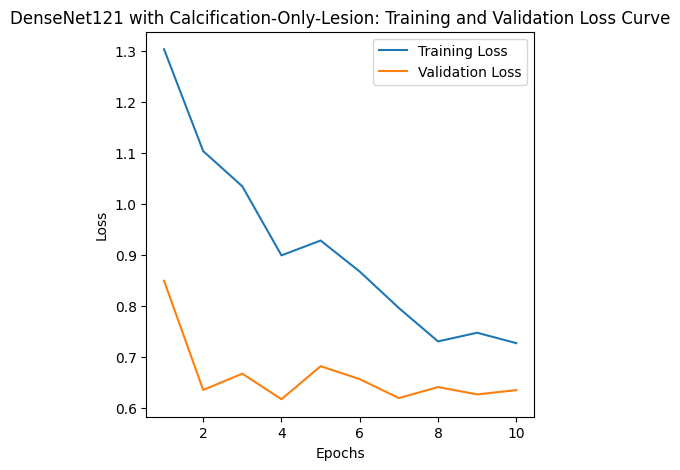

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_c.history, 'DenseNet121', 'Calcification-Only-Lesion')

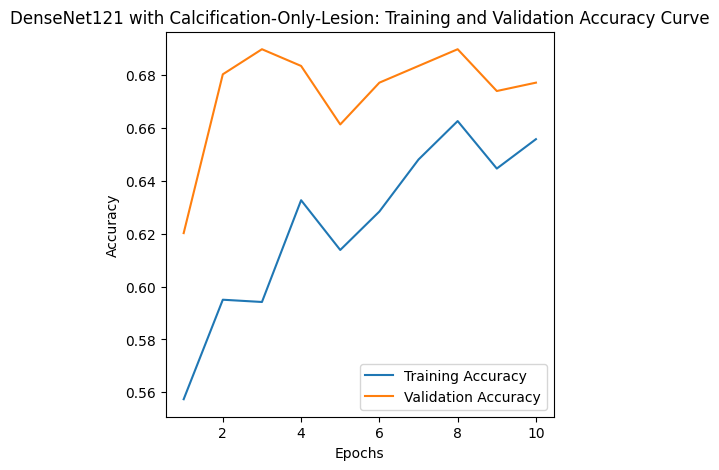

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(densenet121_c.history, 'DenseNet121', 'Calcification-Only-Lesion')

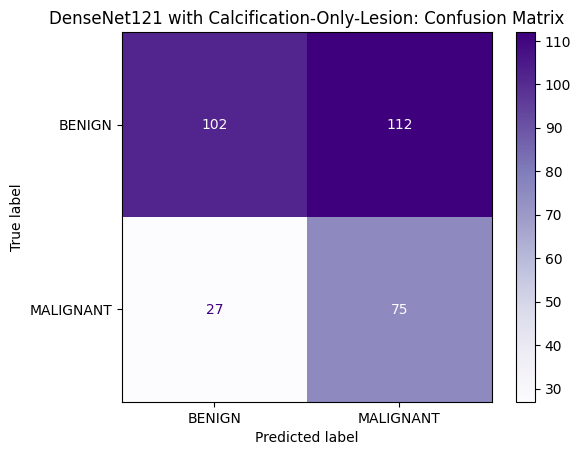

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_c, predictions_densenet121_c, 'DenseNet121', 'Calcification-Only-Lesion')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_c = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_c, train_time_mobilenetv2_c, peak_memory_mobilenetv2_c = train_selected_model(mobilenetv2_model_c,
                                                                                          train_dataset_c,
                                                                                          val_dataset_c,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict_c)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 25s 461ms/step - accuracy: 0.5830 - auc: 0.5394 - loss: 0.7439 - precision: 0.3656 - recall: 0.2918 - val_accuracy: 0.6899 - val_auc: 0.5737 - val_loss: 0.6198 - val_precision: 0.6250 - val_recall: 0.0980
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 423ms/step - accuracy: 0.6293 - auc: 0.5905 - loss: 0.7027 - precision: 0.4494 - recall: 0.3541 - val_accuracy: 0.5696 - val_auc: 0.6632 - val_loss: 0.7674 - val_precision: 0.4012 - val_recall: 0.6765
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 421ms/step - accuracy: 0.6318 - auc: 0.5990 - loss: 0.6924 - precision: 0.4557 - recall: 0.3716 - val_accuracy: 0.6899 - val_auc: 0.6665 - val_loss: 0.6872 - val_precision: 0.5312 - val_recall: 0.3333
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 423ms/step - accuracy: 0.6490 - auc: 0.6334 - loss: 0.6655 - precision: 0.4861 - recall: 0.3915 - val_accuracy: 0.6835 - val_auc: 0.6168 - val_loss: 0.6266 - val_precision: 0.5385 

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
logits_mobilenetv2_c, predictions_mobilenetv2_c, metrics_dict_mobilenetv2_c, infer_time_mobilenetv2_c = generate_predictions_and_evaluations(mobilenetv2_c,
                                                                                                                                             val_dataset_c,
                                                                                                                                             val_true_labels_c,
                                                                                                                                             PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 273ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 0.6899 - auc: 0.5737 - loss: 0.6198 - precision: 0.6250 - recall: 0.0980


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_c_results_df = generate_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_mobilenetv2_c,
    train_time=train_time_mobilenetv2_c,
    infer_time=infer_time_mobilenetv2_c,
    peak_memory=peak_memory_mobilenetv2_c,
    experiment_type='lesions'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_c_results_df, 'lesion')

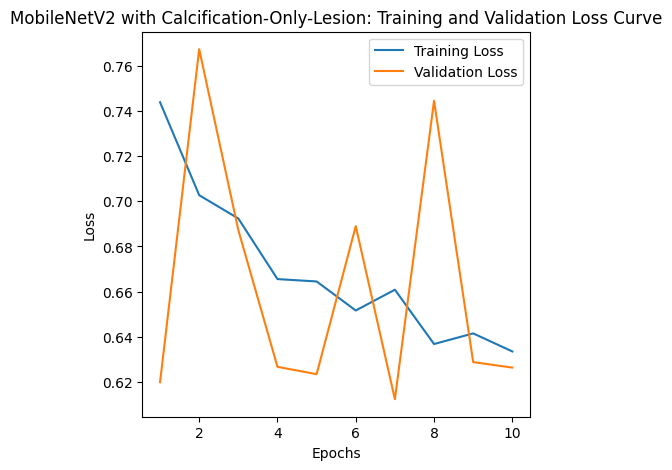

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_c.history, 'MobileNetV2', 'Calcification-Only-Lesion')

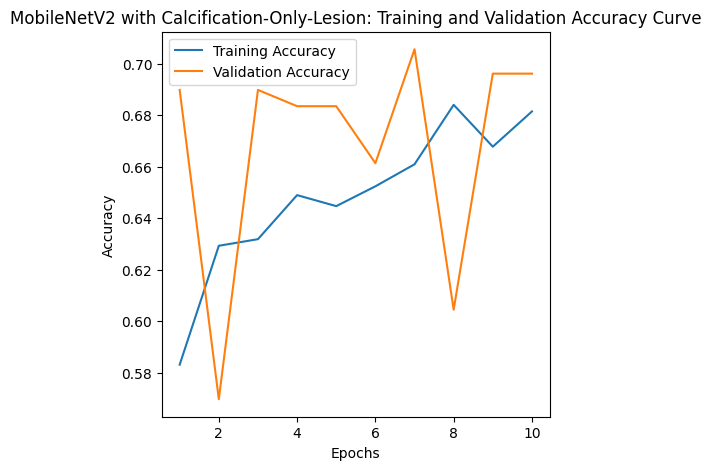

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(mobilenetv2_c.history, 'MobileNetV2', 'Calcification-Only-Lesion')

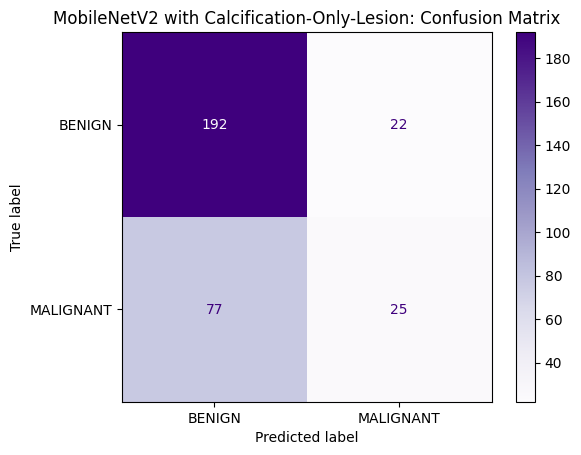

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_c, predictions_mobilenetv2_c, 'MobileNetV2', 'Calcification-Only-Lesion')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_c = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_c, train_time_efficientnetb0_c, peak_memory_efficientnetb0_c = train_selected_model(efficientnetb0_model_c,
                                                                                                   train_dataset_c,
                                                                                                   val_dataset_c,
                                                                                                   EXPERIMENTAL_EPOCHS,
                                                                                                   early_stopping,
                                                                                                   class_weights_dict_c)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 33s 528ms/step - accuracy: 0.6747 - auc: 0.6100 - loss: 0.6551 - precision: 0.5755 - recall: 0.1995 - val_accuracy: 0.7089 - val_auc: 0.7325 - val_loss: 0.5886 - val_precision: 0.6087 - val_recall: 0.2745
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 446ms/step - accuracy: 0.6807 - auc: 0.6861 - loss: 0.6071 - precision: 0.5461 - recall: 0.4140 - val_accuracy: 0.7120 - val_auc: 0.6543 - val_loss: 0.5334 - val_precision: 0.7619 - val_recall: 0.1569
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 435ms/step - accuracy: 0.6755 - auc: 0.6671 - loss: 0.5979 - precision: 0.5396 - recall: 0.3741 - val_accuracy: 0.7120 - val_auc: 0.6592 - val_loss: 0.5305 - val_precision: 0.6571 - val_recall: 0.2255
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 441ms/step - accuracy: 0.6901 - auc: 0.7066 - loss: 0.5786 - precision: 0.5615 - recall: 0.4439 - val_accuracy: 0.7120 - val_auc: 0.6415 - val_loss: 0.5188 - val_precision: 0.657

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
logits_efficientnetb0_c, predictions_efficientnetb0_c, metrics_dict_efficientnetb0_c, infer_time_efficientnetb0_c = generate_predictions_and_evaluations(
                                                                                                                               efficientnetb0_c,
                                                                                                                               val_dataset_c,
                                                                                                                               val_true_labels_c,
                                                                                                                               PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 515ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step - accuracy: 0.7089 - auc: 0.7325 - loss: 0.5886 - precision: 0.6087 - recall: 0.2745


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_c_results_df = generate_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_efficientnetb0_c,
    train_time=train_time_efficientnetb0_c,
    infer_time=infer_time_efficientnetb0_c,
    peak_memory=peak_memory_efficientnetb0_c,
    experiment_type='lesions'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_c_results_df, 'lesions')

Stored results for 0    Calcification-Only-Lesion
Name: lesion_type, dtype: object lesions


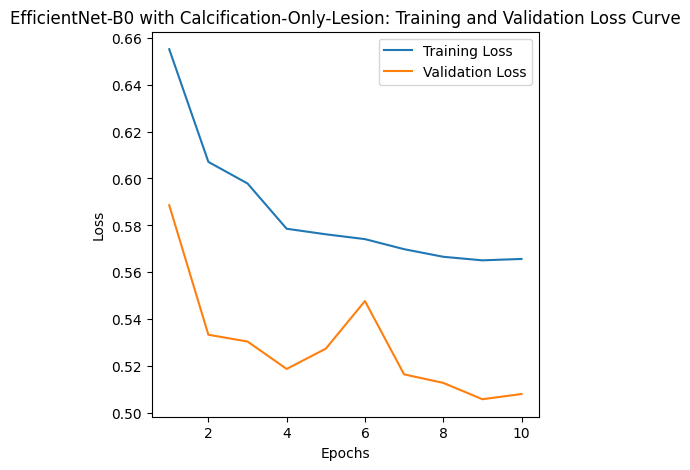

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_c.history, 'EfficientNet-B0', 'Calcification-Only-Lesion')

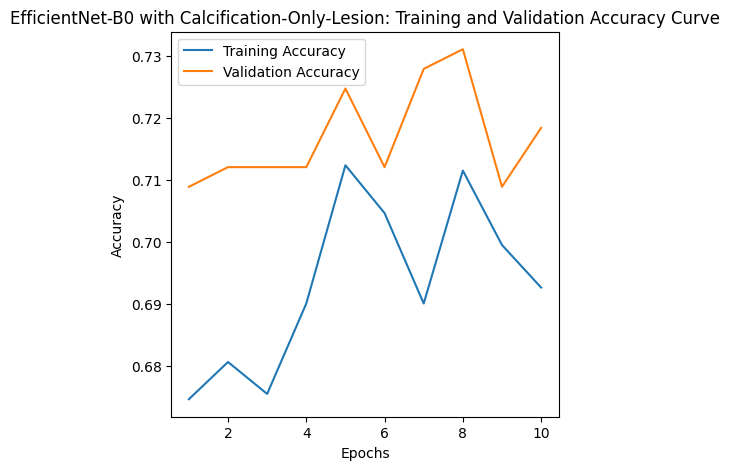

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(efficientnetb0_c.history, 'EfficientNet-B0', 'Calcification-Only-Lesion')

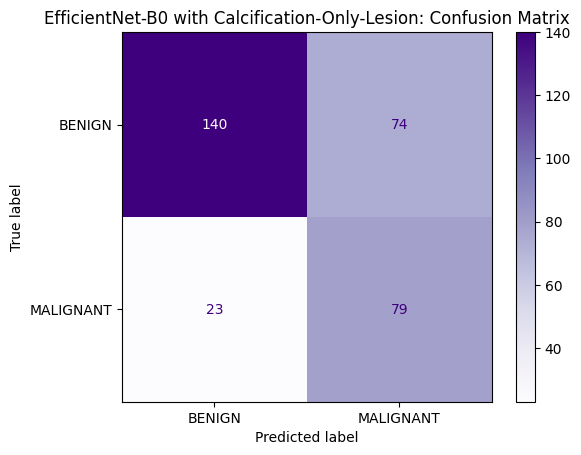

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_c, predictions_efficientnetb0_c, 'EfficientNet-B0', 'Calcification-Only-Lesion')

## Mass Lesion Only Experiment

#### tf.data Datasets for Mass-only Lesion

In [ ]:
# Generate training and validation datasets for Mass only
train_dataset_m = dataset_preparation(train_df_m, baseline_preprocessor, BUFFER_SIZE_M, BATCH_SIZE, training=True)
val_dataset_m = dataset_preparation(val_df_m, baseline_preprocessor, BUFFER_SIZE_M, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_m = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_m, train_time_vgg16_m, peak_memory_vgg16_m = train_selected_model(vgg16_model_m,
                                                                        train_dataset_m,
                                                                        val_dataset_m,
                                                                        EXPERIMENTAL_EPOCHS,
                                                                        early_stopping,
                                                                        class_weights_dict_m)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 540ms/step - accuracy: 0.5131 - auc: 0.5154 - loss: 1.0403 - precision: 0.4630 - recall: 0.4473 - val_accuracy: 0.5609 - val_auc: 0.5416 - val_loss: 0.7323 - val_precision: 0.5918 - val_recall: 0.2266
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 520ms/step - accuracy: 0.5501 - auc: 0.5457 - loss: 0.8997 - precision: 0.5058 - recall: 0.4334 - val_accuracy: 0.5793 - val_auc: 0.5706 - val_loss: 0.7185 - val_precision: 0.6667 - val_recall: 0.2188
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 505ms/step - accuracy: 0.5628 - auc: 0.5628 - loss: 0.8886 - precision: 0.5236 - recall: 0.4195 - val_accuracy: 0.6052 - val_auc: 0.5845 - val_loss: 0.6992 - val_precision: 0.7059 - val_recall: 0.2812
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 517ms/step - accuracy: 0.5637 - auc: 0.5678 - loss: 0.8030 - precision: 0.5243 - recall: 0.4294 - val_accuracy: 0.5904 - val_auc: 0.5995 - val_loss: 0.6955 - val_precision: 0.602

In [ ]:
# Predictions and evaluations using the trained VGG16 model
logits_vgg16_m, predictions_vgg16_m, metrics_dict_vgg16_m, infer_time_vgg16_m = generate_predictions_and_evaluations(vgg16_m,
                                                                                                                     val_dataset_m,
                                                                                                                     val_true_labels_m,
                                                                                                                     PREDICTION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.6052 - auc: 0.6551 - loss: 0.6357 - precision: 0.6721 - recall: 0.3203


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_m_results_df = generate_results_metrics_df(
    model_name='VGG16',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_vgg16_m,
    train_time=train_time_vgg16_m,
    infer_time=infer_time_vgg16_m,
    peak_memory=peak_memory_vgg16_m,
    experiment_type='lesions'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_m_results_df, 'lesions')

Stored results for 0    Mass-Only-Lesion
Name: lesion_type, dtype: object lesions


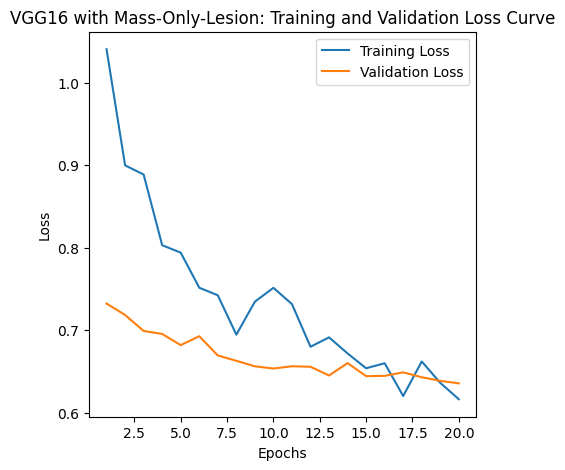

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_m.history, 'VGG16', 'Mass-Only-Lesion')

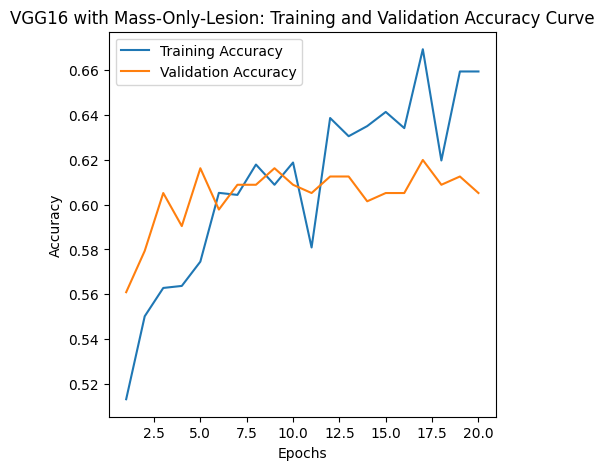

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(vgg16_m.history, 'VGG16', 'Mass-Only-Lesion')

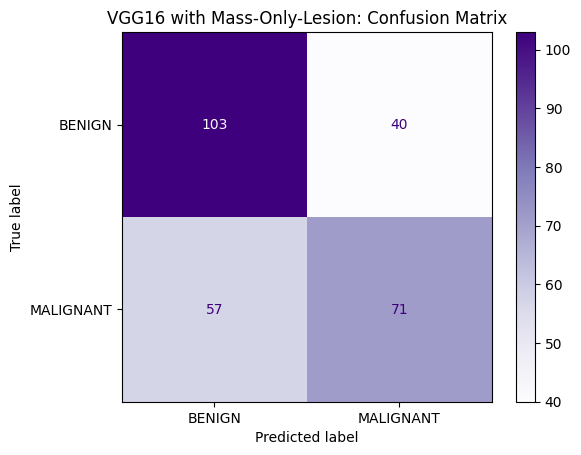

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_m, predictions_vgg16_m, 'VGG16', 'Mass-Only-Lesion')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_m = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_m, train_time_resnet50_m, peak_memory_resnet50_m = train_selected_model(resnet50_model_m,
                                                                                 train_dataset_m,
                                                                                 val_dataset_m,
                                                                                 EXPERIMENTAL_EPOCHS,
                                                                                 early_stopping,
                                                                                 class_weights_dict_m)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 576ms/step - accuracy: 0.5556 - auc: 0.5435 - loss: 0.7379 - precision: 0.5168 - recall: 0.3360 - val_accuracy: 0.5904 - val_auc: 0.6149 - val_loss: 0.6788 - val_precision: 0.7429 - val_recall: 0.2031
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 512ms/step - accuracy: 0.6007 - auc: 0.6194 - loss: 0.6949 - precision: 0.5827 - recall: 0.4274 - val_accuracy: 0.5830 - val_auc: 0.6406 - val_loss: 0.6814 - val_precision: 0.8571 - val_recall: 0.1406
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 526ms/step - accuracy: 0.6170 - auc: 0.6330 - loss: 0.6582 - precision: 0.6145 - recall: 0.4215 - val_accuracy: 0.6199 - val_auc: 0.6546 - val_loss: 0.6605 - val_precision: 0.8788 - val_recall: 0.2266
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 499ms/step - accuracy: 0.6251 - auc: 0.6657 - loss: 0.6362 - precision: 0.6375 - recall: 0.4056 - val_accuracy: 0.6605 - val_auc: 0.6772 - val_loss: 0.6372 - val_precision: 0.846

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
logits_resnet50_m, predictions_resnet50_m, metrics_dict_resnet50_m, infer_time_resnet50_m = generate_predictions_and_evaluations(resnet50_m,
                                                                                                                                 val_dataset_m,
                                                                                                                                 val_true_labels_m,
                                                                                                                                 PREDICTION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 485ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.7085 - auc: 0.7467 - loss: 0.5755 - precision: 0.8267 - recall: 0.4844


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_m_results_df = generate_results_metrics_df(
    model_name='ResNet50',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_resnet50_m,
    train_time=train_time_resnet50_m,
    infer_time=infer_time_resnet50_m,
    peak_memory=peak_memory_resnet50_m,
    experiment_type='lesions'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_m_results_df, 'lesions')

Stored results for 0    Mass-Only-Lesion
Name: lesion_type, dtype: object lesions


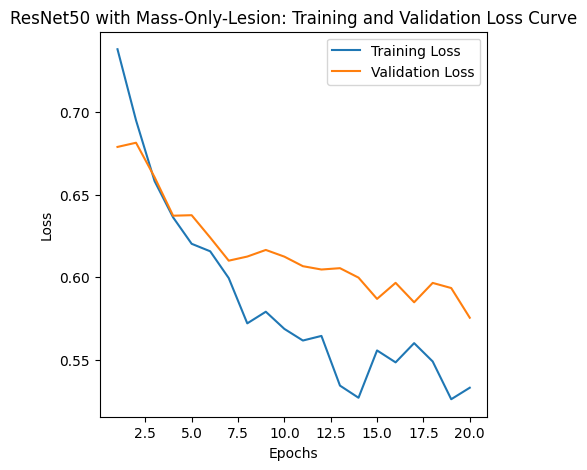

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_m.history, 'ResNet50', 'Mass-Only-Lesion')

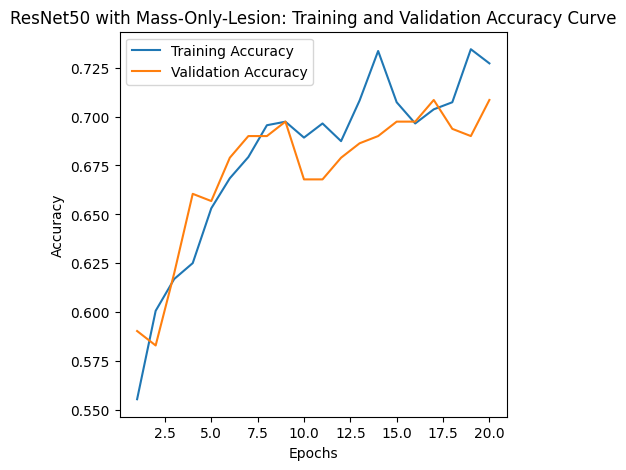

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(resnet50_m.history, 'ResNet50', 'Mass-Only-Lesion')

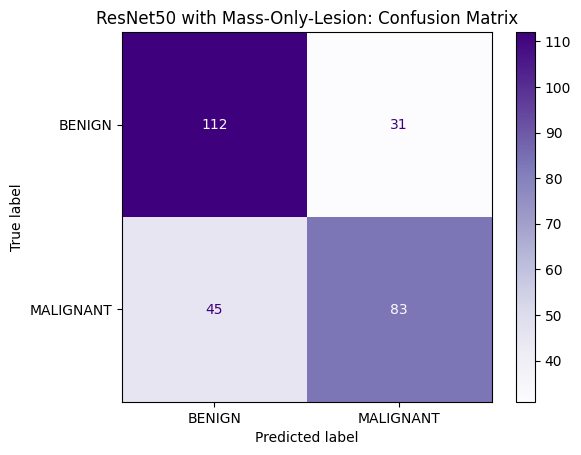

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_m, predictions_resnet50_m, 'ResNet50', 'Mass-Only-Lesion')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_m = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_m, train_time_densenet121_m, peak_memory_densenet121_m = train_selected_model(densenet121_model_m,
                                                                                          train_dataset_m,
                                                                                          val_dataset_m,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict_m)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 39s 657ms/step - accuracy: 0.5104 - auc: 0.5000 - loss: 1.5178 - precision: 0.4584 - recall: 0.4274 - val_accuracy: 0.5756 - val_auc: 0.5716 - val_loss: 0.7396 - val_precision: 0.5747 - val_recall: 0.3906
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 507ms/step - accuracy: 0.5104 - auc: 0.5022 - loss: 1.3918 - precision: 0.4586 - recall: 0.4294 - val_accuracy: 0.5830 - val_auc: 0.5668 - val_loss: 0.6971 - val_precision: 0.6744 - val_recall: 0.2266
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 506ms/step - accuracy: 0.5474 - auc: 0.5428 - loss: 1.1939 - precision: 0.5022 - recall: 0.4513 - val_accuracy: 0.5572 - val_auc: 0.5587 - val_loss: 0.7384 - val_precision: 0.6538 - val_recall: 0.1328
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 527ms/step - accuracy: 0.5691 - auc: 0.5700 - loss: 1.0709 - precision: 0.5322 - recall: 0.4274 - val_accuracy: 0.6162 - val_auc: 0.6250 - val_loss: 0.6808 - val_precision: 0.662

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
logits_densenet121_m, predictions_densenet121_m, metrics_dict_densenet121_m, infer_time_densenet121_m = generate_predictions_and_evaluations(densenet121_m,
                                                                                                                                             val_dataset_m,
                                                                                                                                             val_true_labels_m,
                                                                                                                                             PREDICTION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 769ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.5756 - auc: 0.5716 - loss: 0.7396 - precision: 0.5747 - recall: 0.3906


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_m_results_df = generate_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_densenet121_m,
    train_time=train_time_densenet121_m,
    infer_time=infer_time_densenet121_m,
    peak_memory=peak_memory_densenet121_m,
    experiment_type='lesions'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_m_results_df, 'lesions')

Stored results for 0    Mass-Only-Lesion
Name: lesion_type, dtype: object lesions


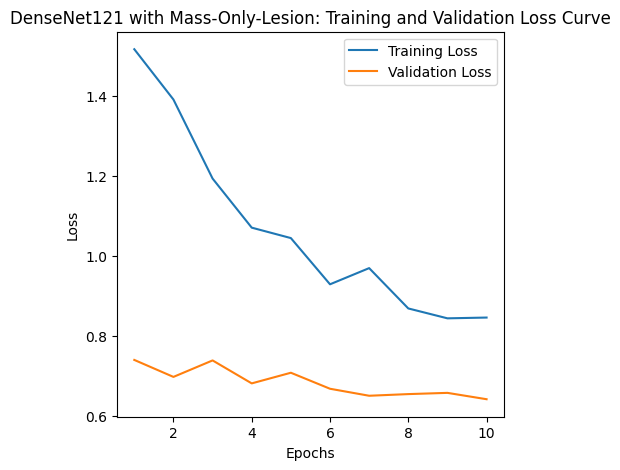

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_m.history, 'DenseNet121', 'Mass-Only-Lesion')

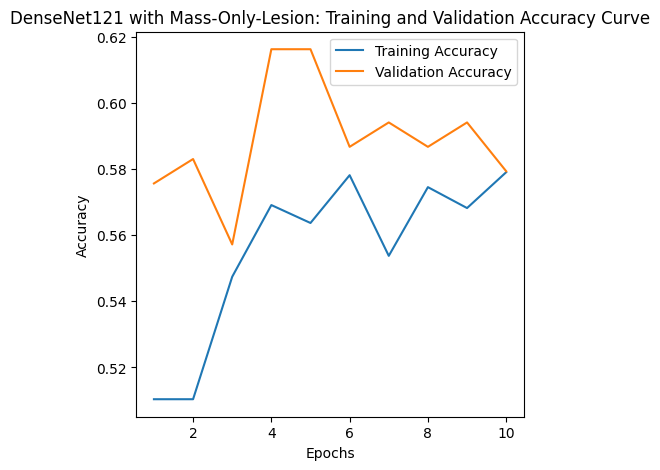

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(densenet121_m.history, 'DenseNet121', 'Mass-Only-Lesion')

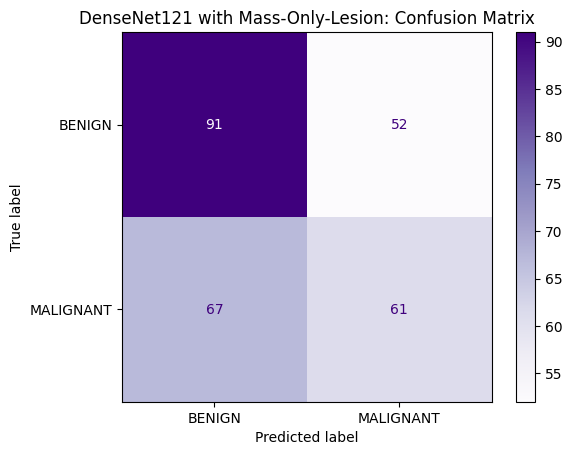

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_m, predictions_densenet121_m, 'DenseNet121', 'Mass-Only-Lesion')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_m = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_m, train_time_mobilenetv2_m, peak_memory_mobilenetv2_m = train_selected_model(mobilenetv2_model_m,
                                                                                          train_dataset_m,
                                                                                          val_dataset_m,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict_m)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 25s 510ms/step - accuracy: 0.5321 - auc: 0.5173 - loss: 0.7592 - precision: 0.4762 - recall: 0.2982 - val_accuracy: 0.5314 - val_auc: 0.5653 - val_loss: 0.6874 - val_precision: 1.0000 - val_recall: 0.0078
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 444ms/step - accuracy: 0.5339 - auc: 0.5324 - loss: 0.7431 - precision: 0.4764 - recall: 0.2604 - val_accuracy: 0.5683 - val_auc: 0.5963 - val_loss: 0.6831 - val_precision: 0.8235 - val_recall: 0.1094
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 446ms/step - accuracy: 0.5492 - auc: 0.5335 - loss: 0.7322 - precision: 0.5070 - recall: 0.2883 - val_accuracy: 0.5830 - val_auc: 0.5845 - val_loss: 0.6840 - val_precision: 0.8000 - val_recall: 0.1562
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 452ms/step - accuracy: 0.5890 - auc: 0.5847 - loss: 0.6904 - precision: 0.5857 - recall: 0.3260 - val_accuracy: 0.5498 - val_auc: 0.5808 - val_loss: 0.6762 - val_precision: 0.7500 

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
logits_mobilenetv2_m, predictions_mobilenetv2_m, metrics_dict_mobilenetv2_m, infer_time_mobilenetv2_m = generate_predictions_and_evaluations(mobilenetv2_m,
                                                                                                                                             val_dataset_m,
                                                                                                                                             val_true_labels_m,
                                                                                                                                             PREDICTION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 248ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.5314 - auc: 0.5653 - loss: 0.6874 - precision: 1.0000 - recall: 0.0078


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_m_results_df = generate_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_mobilenetv2_m,
    train_time=train_time_mobilenetv2_m,
    infer_time=infer_time_mobilenetv2_m,
    peak_memory=peak_memory_mobilenetv2_m,
    experiment_type='lesions'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_m_results_df, 'lesions')

Stored results for 0    Mass-Only-Lesion
Name: lesion_type, dtype: object lesions


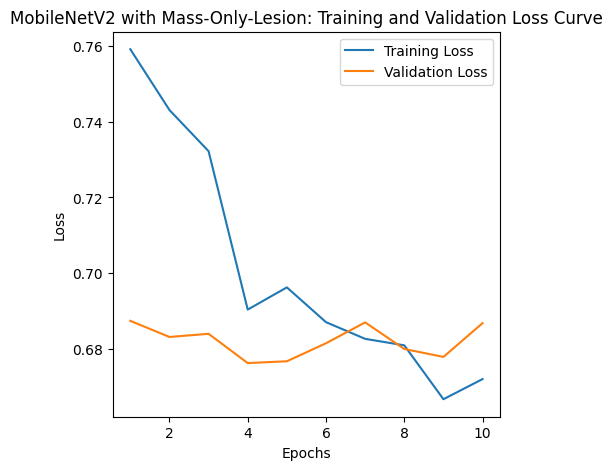

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_m.history, 'MobileNetV2', 'Mass-Only-Lesion')

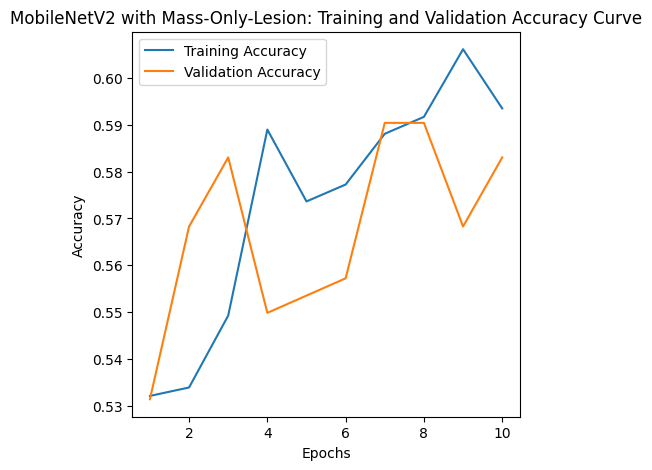

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(mobilenetv2_m.history, 'MobileNetV2', 'Mass-Only-Lesion')

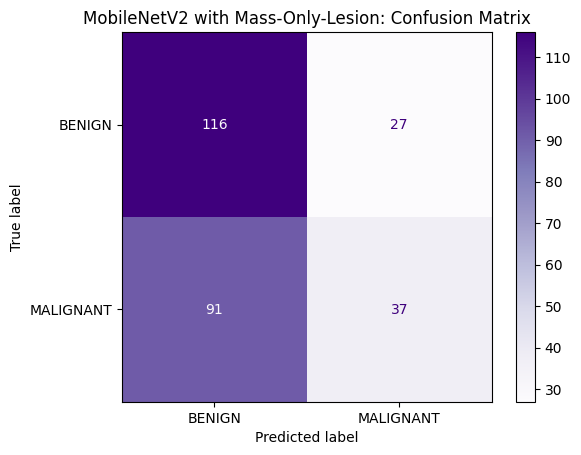

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_m, predictions_mobilenetv2_m, 'MobileNetV2', 'Mass-Only-Lesion')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_m = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_m, train_time_efficientnetb0_m, peak_memory_efficientnetb0_m = train_selected_model(efficientnetb0_model_m,
                                                                                                   train_dataset_m,
                                                                                                   val_dataset_m,
                                                                                                   EXPERIMENTAL_EPOCHS,
                                                                                                   early_stopping,
                                                                                                   class_weights_dict_m)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 549ms/step - accuracy: 0.5709 - auc: 0.5956 - loss: 0.6697 - precision: 0.6129 - recall: 0.1511 - val_accuracy: 0.5904 - val_auc: 0.5989 - val_loss: 0.6676 - val_precision: 0.8696 - val_recall: 0.1562
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 461ms/step - accuracy: 0.6251 - auc: 0.6746 - loss: 0.6357 - precision: 0.6930 - recall: 0.3141 - val_accuracy: 0.5830 - val_auc: 0.6198 - val_loss: 0.6574 - val_precision: 1.0000 - val_recall: 0.1172
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 466ms/step - accuracy: 0.6369 - auc: 0.6742 - loss: 0.6270 - precision: 0.7061 - recall: 0.3439 - val_accuracy: 0.6310 - val_auc: 0.6481 - val_loss: 0.6474 - val_precision: 0.8889 - val_recall: 0.2500
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 457ms/step - accuracy: 0.6531 - auc: 0.6952 - loss: 0.6225 - precision: 0.7390 - recall: 0.3658 - val_accuracy: 0.6273 - val_auc: 0.6715 - val_loss: 0.6409 - val_precision: 0.754

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
logits_efficientnetb0_m, predictions_efficientnetb0_m, metrics_dict_efficientnetb0_m, infer_time_efficientnetb0_m = generate_predictions_and_evaluations(
                                                                                                                                       efficientnetb0_m,
                                                                                                                                       val_dataset_m,
                                                                                                                                       val_true_labels_m,
                                                                                                                                       PREDICTION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 382ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5904 - auc: 0.5989 - loss: 0.6676 - precision: 0.8696 - recall: 0.1562


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_m_results_df = generate_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_efficientnetb0_m,
    train_time=train_time_efficientnetb0_m,
    infer_time=infer_time_efficientnetb0_m,
    peak_memory=peak_memory_efficientnetb0_m,
    experiment_type='lesions'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_m_results_df, 'lesions')

Stored results for 0    Mass-Only-Lesion
Name: lesion_type, dtype: object lesions


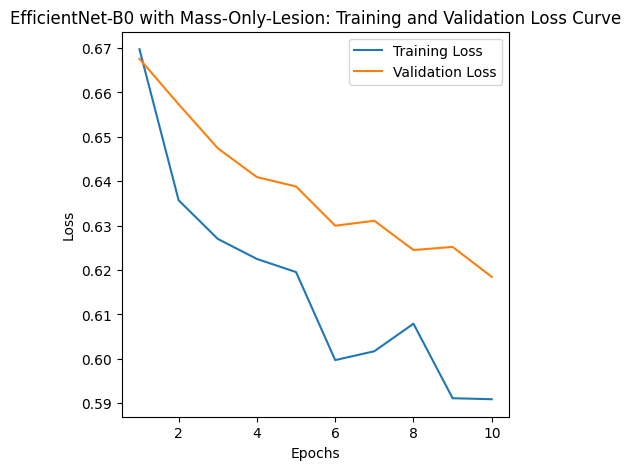

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_m.history, 'EfficientNet-B0', 'Mass-Only-Lesion')

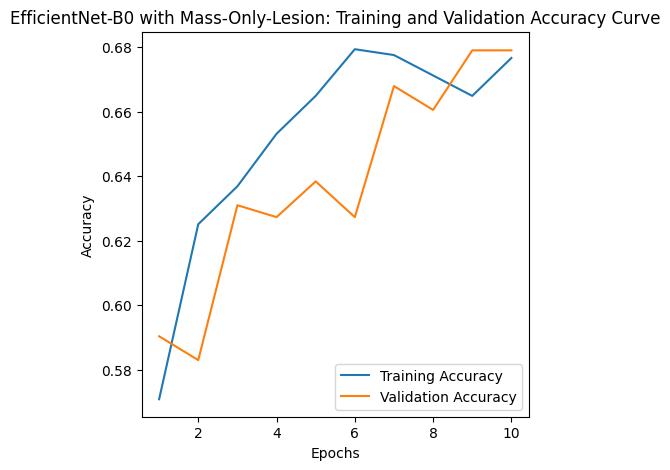

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(efficientnetb0_m.history, 'EfficientNet-B0', 'Mass-Only-Lesion')

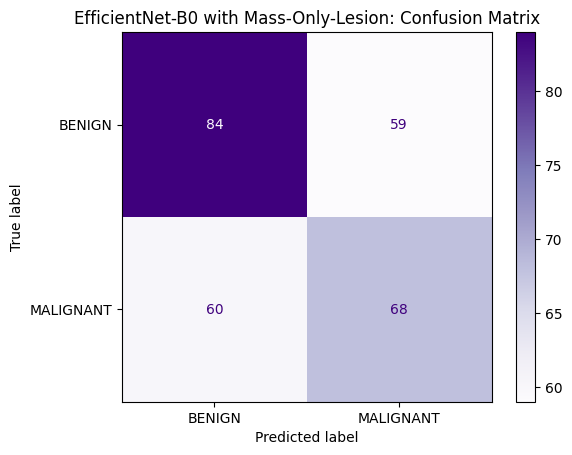

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_m, predictions_efficientnetb0_m, 'EfficientNet-B0', 'Mass-Only-Lesion')